In [22]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.model_selection import GridSearchCV
import warnings

warnings.filterwarnings("ignore")
ln = LabelEncoder()
trreg = DecisionTreeRegressor()

In [2]:
data = pd.read_csv("Company_Data.csv")

In [3]:
data.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [4]:
data.isna().sum()

Sales          0
CompPrice      0
Income         0
Advertising    0
Population     0
Price          0
ShelveLoc      0
Age            0
Education      0
Urban          0
US             0
dtype: int64

In [5]:
data.dtypes

Sales          float64
CompPrice        int64
Income           int64
Advertising      int64
Population       int64
Price            int64
ShelveLoc       object
Age              int64
Education        int64
Urban           object
US              object
dtype: object

In [6]:
real_data = data.copy()

In [7]:
real_data

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...
395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes
396,6.14,139,23,3,37,120,Medium,55,11,No,Yes
397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes
398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes


In [8]:
real_data.ShelveLoc = ln.fit_transform(real_data.ShelveLoc)
real_data.Urban = ln.fit_transform(real_data.Urban)
real_data.US = ln.fit_transform(real_data.US)

In [9]:
real_data.dtypes

Sales          float64
CompPrice        int64
Income           int64
Advertising      int64
Population       int64
Price            int64
ShelveLoc        int32
Age              int64
Education        int64
Urban            int32
US               int32
dtype: object

In [10]:
x = real_data.drop(labels="Sales",axis = 1)
y = real_data[["Sales"]]

In [11]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=12,test_size=0.30)

In [12]:
DecisionTreeRegressor(criterion='mse',
    splitter='best',
    max_depth=None,)

DecisionTreeRegressor()

In [13]:
grcv = GridSearchCV(trreg,param_grid={ "criterion":("mse", "friedman_mse", "mae", "poisson"),
    "splitter":('best',"andom"),
    "max_depth":(1,2,3,4,5,6,7,8),
    })

In [14]:
grcv.fit(x,y)
print("best figures are : ",grcv.best_params_)

best figures are :  {'criterion': 'mse', 'max_depth': 7, 'splitter': 'best'}


In [15]:
grcv.best_estimator_

DecisionTreeRegressor(max_depth=7)

In [18]:
trreg = DecisionTreeRegressor(max_depth=6,criterion="friedman_mse")
trreg.fit(x_train,y_train)
y_test_pred = trreg.predict(x_test)
y_train_pred = trreg.predict(x_train)
res(y_train_pred,y_test_pred,y_train,y_test)

For Test Data 
Mean Squared Error     5.183357179281907
Mean Absolute Error    1.8318616217578716
For Train Data 
Mean Squared Error     1.2169262149919524
Mean Absolute Error    0.8302734756513328


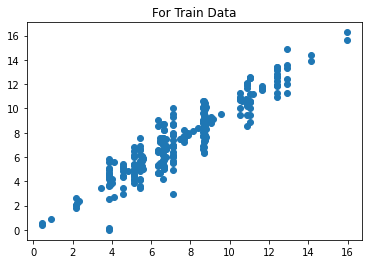

In [19]:
plt.title("For Train Data")
plt.scatter(x = y_train_pred,y = y_train)
plt.show()

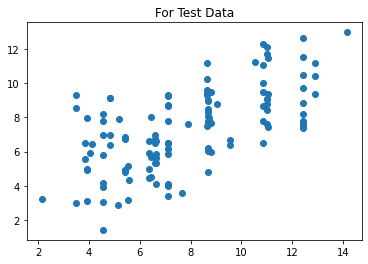

In [20]:
plt.title("For Test Data")
print(plt.scatter(x = y_test_pred,y = y_test))
plt.show()

### User Difined Functions

In [17]:
def res(y_train_pre,y_test_pre,y_train,y_test):
    print("For Test Data ")
    print("Mean Squared Error    ", mean_squared_error (y_test_pre,y_test))
    print("Mean Absolute Error   ", mean_absolute_error (y_test_pre,y_test))
    print("========================")
    print("For Train Data ")
    print("Mean Squared Error    ", mean_squared_error (y_train_pre,y_train))
    print("Mean Absolute Error   ", mean_absolute_error (y_train_pre,y_train))